# AIL7370 : DL4CV
# Assignment 9: Detection and Segmentation

# Anuj Rajan Lalla (B22AI061)

# Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, random_split
import torchvision
import torchvision.transforms as T
import torchvision.models as models
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import random
import math
import os
import warnings
warnings.filterwarnings("ignore")

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [3]:
# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Helper Functions

In [4]:
def compute_iou(box1, box2):
    """Compute IoU between two sets of boxes in [x1, y1, x2, y2] format.
    box1: (N, 4), box2: (M, 4)
    Returns: (N, M) IoU matrix.
    """
    x1 = torch.max(box1[:, None, 0], box2[None, :, 0])
    y1 = torch.max(box1[:, None, 1], box2[None, :, 1])
    x2 = torch.min(box1[:, None, 2], box2[None, :, 2])
    y2 = torch.min(box1[:, None, 3], box2[None, :, 3])
    inter = (x2 - x1).clamp(min=0) * (y2 - y1).clamp(min=0)
    area1 = (box1[:, 2] - box1[:, 0]) * (box1[:, 3] - box1[:, 1])
    area2 = (box2[:, 2] - box2[:, 0]) * (box2[:, 3] - box2[:, 1])
    union = area1[:, None] + area2[None, :] - inter
    return inter / (union + 1e-6)


def compute_ap(precisions, recalls):
    """Compute Average Precision using the 11-point interpolation method."""
    ap = 0.0
    for t in np.arange(0, 1.1, 0.1):
        prec_at_recall = precisions[recalls >= t]
        if len(prec_at_recall) > 0:
            ap += prec_at_recall.max()
    return ap / 11.0


def compute_map_from_predictions(all_preds, all_targets, iou_threshold=0.5, num_classes=21):
    """Compute mAP@0.5 across all classes from collected predictions and targets.
    all_preds: list of dicts with 'boxes', 'labels', 'scores'
    all_targets: list of dicts with 'boxes', 'labels'
    """
    aps = []
    for cls in range(1, num_classes):  # skip background
        cls_scores, cls_tp, cls_fp = [], [], []
        n_gt = 0
        for preds, targets in zip(all_preds, all_targets):
            gt_mask = targets["labels"] == cls
            gt_boxes = targets["boxes"][gt_mask]
            n_gt += len(gt_boxes)
            matched = torch.zeros(len(gt_boxes), dtype=torch.bool)

            pred_mask = preds["labels"] == cls
            pred_boxes = preds["boxes"][pred_mask]
            pred_scores = preds["scores"][pred_mask]

            # Sort by score descending
            order = pred_scores.argsort(descending=True)
            for idx in order:
                cls_scores.append(pred_scores[idx].item())
                if len(gt_boxes) == 0:
                    cls_tp.append(0)
                    cls_fp.append(1)
                    continue
                ious = compute_iou(pred_boxes[idx:idx+1], gt_boxes)[0]
                best_iou, best_gt = ious.max(0)
                if best_iou >= iou_threshold and not matched[best_gt]:
                    cls_tp.append(1)
                    cls_fp.append(0)
                    matched[best_gt] = True
                else:
                    cls_tp.append(0)
                    cls_fp.append(1)

        if n_gt == 0:
            continue
        cls_scores = np.array(cls_scores)
        cls_tp = np.array(cls_tp)
        cls_fp = np.array(cls_fp)
        order = cls_scores.argsort()[::-1]
        cls_tp = cls_tp[order]
        cls_fp = cls_fp[order]
        tp_cumsum = cls_tp.cumsum()
        fp_cumsum = cls_fp.cumsum()
        recalls = tp_cumsum / n_gt
        precisions = tp_cumsum / (tp_cumsum + fp_cumsum)
        aps.append(compute_ap(precisions, recalls))

    return np.mean(aps) if len(aps) > 0 else 0.0


def visualize_detections(image, boxes, labels, scores, class_names, threshold=0.5, title=""):
    """Draw bounding boxes on an image with class labels and scores."""
    fig, ax = plt.subplots(1, figsize=(10, 8))
    if isinstance(image, torch.Tensor):
        image = image.permute(1, 2, 0).cpu().numpy()
    image = np.clip(image, 0, 1)
    ax.imshow(image)
    colors = plt.cm.tab20(np.linspace(0, 1, 21))
    for i in range(len(boxes)):
        if scores[i] < threshold:
            continue
        x1, y1, x2, y2 = boxes[i]
        cls = labels[i]
        color = colors[cls % 20]
        rect = mpatches.FancyBboxPatch(
            (x1, y1), x2 - x1, y2 - y1, linewidth=2,
            edgecolor=color, facecolor="none"
        )
        ax.add_patch(rect)
        name = class_names[cls] if cls < len(class_names) else str(cls)
        ax.text(x1, y1 - 5, f"{name}: {scores[i]:.2f}", color=color,
                fontsize=9, fontweight="bold", backgroundcolor="black")
    ax.set_title(title)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

---
# Part 1: Object Detection (Faster R-CNN vs. DETR)
Comparing the traditional proposal-based Faster R-CNN with the modern end-to-end Transformer-based DETR on PASCAL VOC 2012. Both models use a ResNet-50 backbone.

## Data Acquisition
### Loading PASCAL VOC 2012
PASCAL VOC 2012 contains 20 object categories. Images are loaded with bounding box annotations converted to the format expected by torchvision detection models.

In [5]:
VOC_CLASSES = [
    "__background__", "aeroplane", "bicycle", "bird", "boat", "bottle",
    "bus", "car", "cat", "chair", "cow", "diningtable", "dog",
    "horse", "motorbike", "person", "pottedplant", "sheep", "sofa",
    "train", "tvmonitor"
]
NUM_VOC_CLASSES = len(VOC_CLASSES)  # 21 including background
print(f"Number of classes (with background): {NUM_VOC_CLASSES}")
print(f"Classes: {VOC_CLASSES[1:]}")

Number of classes (with background): 21
Classes: ['aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor']


In [6]:
import xml.etree.ElementTree as ET
from PIL import Image


class VOCDetectionDataset(Dataset):
    """PASCAL VOC 2012 detection dataset.
    Parses XML annotations to extract bounding boxes and class labels.
    Returns image tensors and target dicts compatible with torchvision detection models.
    """

    def __init__(self, root, year="2012", image_set="train", transforms=None, max_samples=None):
        self.root = root
        self.transforms = transforms
        self.class_to_idx = {c: i for i, c in enumerate(VOC_CLASSES)}

        # Load the dataset to get file paths
        voc = torchvision.datasets.VOCDetection(
            root=root, year=year, image_set=image_set, download=True
        )
        self.images = []
        self.annotations = []
        for i in range(len(voc)):
            img, target = voc[i]
            objs = target["annotation"]["object"]
            if not isinstance(objs, list):
                objs = [objs]
            # Filter out difficult objects
            valid_objs = [o for o in objs if int(o.get("difficult", 0)) == 0]
            if len(valid_objs) > 0:
                self.images.append(img)
                self.annotations.append(valid_objs)
            # Cap at max_samples to keep training feasible on Colab
            if max_samples is not None and len(self.images) >= max_samples:
                break

        print(f"Loaded {len(self.images)} images from VOC {year} ({image_set})")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        objs = self.annotations[idx]

        boxes, labels = [], []
        for obj in objs:
            bbox = obj["bndbox"]
            x1 = float(bbox["xmin"])
            y1 = float(bbox["ymin"])
            x2 = float(bbox["xmax"])
            y2 = float(bbox["ymax"])
            if x2 > x1 and y2 > y1:
                boxes.append([x1, y1, x2, y2])
                labels.append(self.class_to_idx[obj["name"]])

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)

        # Convert PIL to tensor
        img_tensor = T.ToTensor()(img)

        if self.transforms is not None:
            img_tensor = self.transforms(img_tensor)

        target = {"boxes": boxes, "labels": labels, "image_id": torch.tensor([idx])}
        return img_tensor, target

In [7]:
# Load VOC 2012 train and val splits (subset for feasible Colab training)
voc_train_dataset = VOCDetectionDataset(root="./data", year="2012", image_set="train", max_samples=1000)
voc_val_dataset = VOCDetectionDataset(root="./data", year="2012", image_set="val", max_samples=500)

print(f"Train samples: {len(voc_train_dataset)}")
print(f"Val samples: {len(voc_val_dataset)}")

100%|██████████| 2.00G/2.00G [01:12<00:00, 27.6MB/s]


Loaded 1000 images from VOC 2012 (train)
Loaded 500 images from VOC 2012 (val)
Train samples: 1000
Val samples: 500


In [8]:
def collate_fn(batch):
    """Custom collate for detection: images and targets are lists, not stacked."""
    return tuple(zip(*batch))


train_loader = DataLoader(
    voc_train_dataset, batch_size=4, shuffle=True,
    num_workers=2, collate_fn=collate_fn
)
val_loader = DataLoader(
    voc_val_dataset, batch_size=4, shuffle=False,
    num_workers=2, collate_fn=collate_fn
)

## Visualizing VOC Samples
Displaying annotated images with ground-truth bounding boxes and class labels.

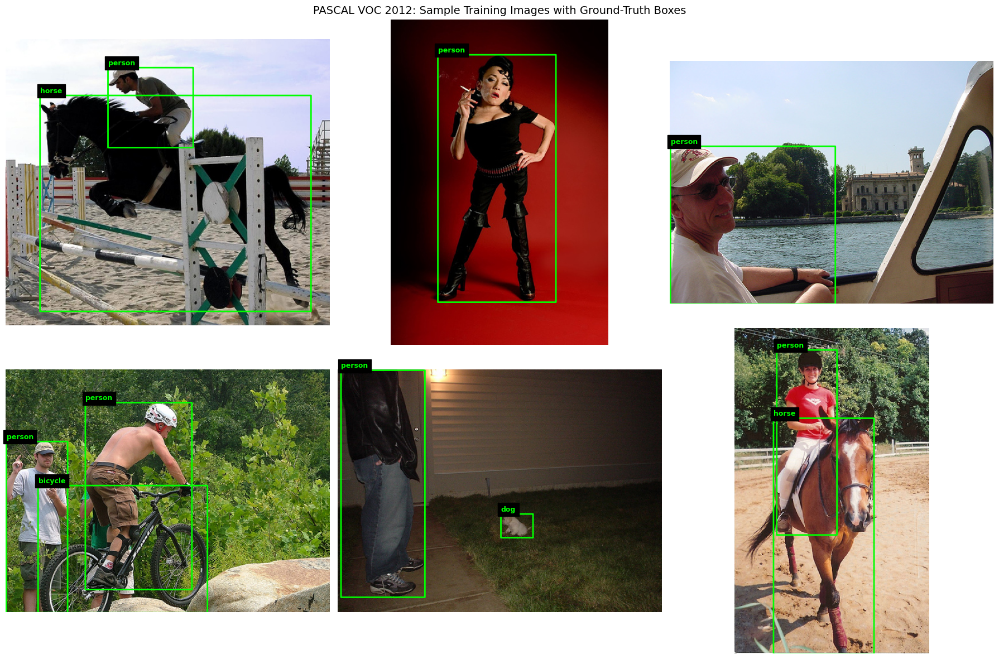

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for i, ax in enumerate(axes.flat):
    img, target = voc_train_dataset[i * 50]
    img_np = img.permute(1, 2, 0).numpy()
    ax.imshow(np.clip(img_np, 0, 1))
    for j in range(len(target["boxes"])):
        x1, y1, x2, y2 = target["boxes"][j]
        cls = target["labels"][j].item()
        rect = mpatches.FancyBboxPatch(
            (x1, y1), x2 - x1, y2 - y1, linewidth=2,
            edgecolor="lime", facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(x1, y1 - 4, VOC_CLASSES[cls], color="lime",
                fontsize=9, fontweight="bold", backgroundcolor="black")
    ax.axis("off")
plt.suptitle("PASCAL VOC 2012: Sample Training Images with Ground-Truth Boxes", fontsize=14)
plt.tight_layout()
plt.show()

## Faster R-CNN (Proposal-Based Detection)
Faster R-CNN uses a Region Proposal Network (RPN) to generate candidate bounding boxes (anchors), followed by ROI pooling and a classification/regression head. Non-Maximum Suppression (NMS) is applied post-hoc to remove duplicate detections. We fine-tune a pretrained Faster R-CNN with a ResNet-50-FPN backbone on VOC 2012.

In [10]:
def get_faster_rcnn(num_classes):
    """Load pretrained Faster R-CNN with ResNet-50-FPN and replace the classification head
    for the target number of classes.
    """
    model = fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT)
    # Replace the box predictor head
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model


faster_rcnn = get_faster_rcnn(NUM_VOC_CLASSES).to(device)
print(f"Faster R-CNN parameters: {sum(p.numel() for p in faster_rcnn.parameters()):,}")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 133MB/s]


Faster R-CNN parameters: 41,396,536


### Analyzing Anchors and NMS in Faster R-CNN
The RPN generates anchors at multiple scales and aspect ratios at every spatial location of the feature map. These anchors act as initial guesses for object locations. After classification and regression refinement, NMS filters overlapping boxes by keeping only the highest-scoring detection per region.

In [11]:
# Inspect anchor generator configuration
anchor_gen = faster_rcnn.rpn.anchor_generator
print("Anchor sizes per feature level:", anchor_gen.sizes)
print("Anchor aspect ratios per feature level:", anchor_gen.aspect_ratios)

# NMS thresholds used during inference
print(f"\nRPN NMS threshold: {faster_rcnn.rpn.nms_thresh}")
print(f"ROI NMS threshold (post-detection): {faster_rcnn.roi_heads.nms_thresh}")
print(f"Score threshold: {faster_rcnn.roi_heads.score_thresh}")
print(f"Max detections per image: {faster_rcnn.roi_heads.detections_per_img}")

Anchor sizes per feature level: ((32,), (64,), (128,), (256,), (512,))
Anchor aspect ratios per feature level: ((0.5, 1.0, 2.0), (0.5, 1.0, 2.0), (0.5, 1.0, 2.0), (0.5, 1.0, 2.0), (0.5, 1.0, 2.0))

RPN NMS threshold: 0.7
ROI NMS threshold (post-detection): 0.5
Score threshold: 0.05
Max detections per image: 100


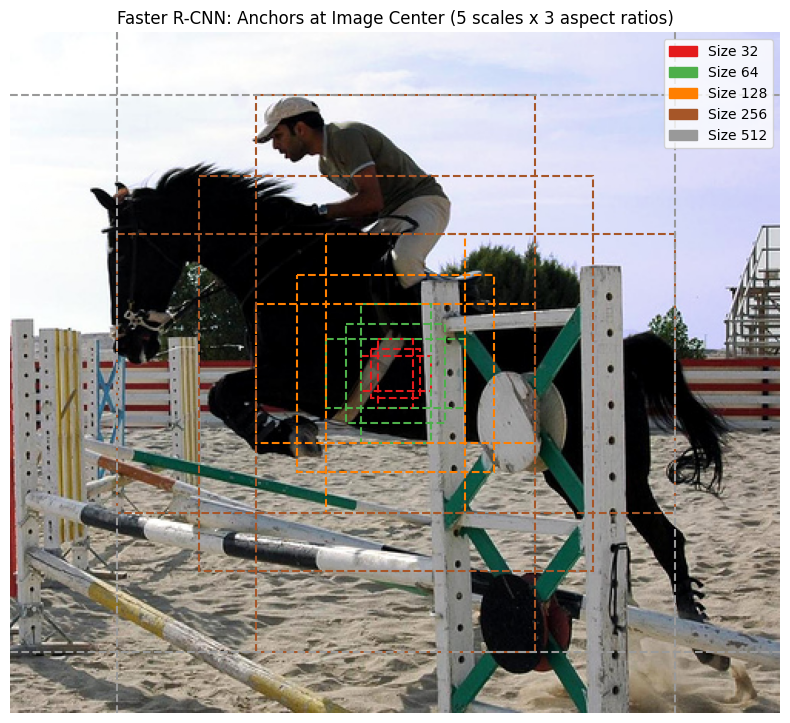

In [12]:
# Visualize anchors at image center for one feature level
sample_img, _ = voc_train_dataset[0]
h, w = sample_img.shape[1], sample_img.shape[2]
cx, cy = w / 2, h / 2

fig, ax = plt.subplots(1, figsize=(8, 8))
ax.imshow(sample_img.permute(1, 2, 0).numpy())

# Generate sample anchors at center
sizes = [32, 64, 128, 256, 512]
ratios = [0.5, 1.0, 2.0]
colors = plt.cm.Set1(np.linspace(0, 1, len(sizes)))
for si, size in enumerate(sizes):
    for ratio in ratios:
        aw = size * math.sqrt(ratio)
        ah = size / math.sqrt(ratio)
        rect = mpatches.Rectangle(
            (cx - aw / 2, cy - ah / 2), aw, ah,
            linewidth=1.5, edgecolor=colors[si], facecolor="none",
            linestyle="--"
        )
        ax.add_patch(rect)

# Legend
legend_patches = [mpatches.Patch(color=colors[i], label=f"Size {s}") for i, s in enumerate(sizes)]
ax.legend(handles=legend_patches, loc="upper right")
ax.set_title("Faster R-CNN: Anchors at Image Center (5 scales x 3 aspect ratios)")
ax.axis("off")
plt.tight_layout()
plt.show()

### Training Faster R-CNN

In [13]:
optimizer_frcnn = optim.SGD(
    faster_rcnn.parameters(), lr=0.005, momentum=0.9, weight_decay=5e-4
)
scheduler_frcnn = optim.lr_scheduler.StepLR(optimizer_frcnn, step_size=3, gamma=0.5)

NUM_EPOCHS_DET = 8
frcnn_train_losses = []

for epoch in range(NUM_EPOCHS_DET):
    faster_rcnn.train()
    epoch_loss = 0.0
    for batch_idx, (images, targets) in enumerate(train_loader):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = faster_rcnn(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer_frcnn.zero_grad()
        losses.backward()
        torch.nn.utils.clip_grad_norm_(faster_rcnn.parameters(), max_norm=5.0)
        optimizer_frcnn.step()

        epoch_loss += losses.item()

    scheduler_frcnn.step()
    avg_loss = epoch_loss / len(train_loader)
    frcnn_train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{NUM_EPOCHS_DET} -- Faster R-CNN Loss: {avg_loss:.4f}")

Epoch 1/8 -- Faster R-CNN Loss: 0.4697
Epoch 2/8 -- Faster R-CNN Loss: 0.2711
Epoch 3/8 -- Faster R-CNN Loss: 0.2155
Epoch 4/8 -- Faster R-CNN Loss: 0.1661
Epoch 5/8 -- Faster R-CNN Loss: 0.1381
Epoch 6/8 -- Faster R-CNN Loss: 0.1266
Epoch 7/8 -- Faster R-CNN Loss: 0.1077
Epoch 8/8 -- Faster R-CNN Loss: 0.0992


### Evaluating Faster R-CNN (mAP@0.5)

In [14]:
@torch.no_grad()
def evaluate_detection(model, data_loader, device, score_thresh=0.3):
    """Run inference and collect all predictions and targets for mAP computation."""
    model.eval()
    all_preds, all_targets = [], []
    for images, targets in data_loader:
        images = [img.to(device) for img in images]
        outputs = model(images)
        for out, tgt in zip(outputs, targets):
            # Filter low-confidence predictions
            keep = out["scores"] >= score_thresh
            pred = {
                "boxes": out["boxes"][keep].cpu(),
                "labels": out["labels"][keep].cpu(),
                "scores": out["scores"][keep].cpu(),
            }
            all_preds.append(pred)
            all_targets.append({k: v.cpu() for k, v in tgt.items()})
    return all_preds, all_targets


frcnn_preds, frcnn_targets = evaluate_detection(faster_rcnn, val_loader, device)
frcnn_map = compute_map_from_predictions(frcnn_preds, frcnn_targets, iou_threshold=0.5, num_classes=NUM_VOC_CLASSES)
print(f"Faster R-CNN mAP@0.5: {frcnn_map:.4f}")

Faster R-CNN mAP@0.5: 0.6962


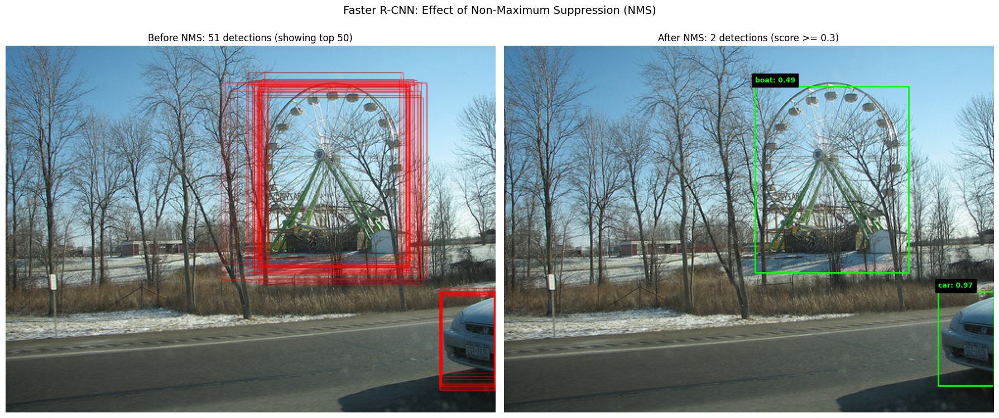

In [15]:
# Visualize NMS effect: show detections before and after NMS
faster_rcnn.eval()
sample_img, sample_target = voc_val_dataset[10]

with torch.no_grad():
    # Get predictions with a low threshold to see many boxes
    faster_rcnn.roi_heads.score_thresh = 0.05
    faster_rcnn.roi_heads.nms_thresh = 1.0  # Disable NMS
    raw_out = faster_rcnn([sample_img.to(device)])[0]

    # Restore NMS
    faster_rcnn.roi_heads.score_thresh = 0.05
    faster_rcnn.roi_heads.nms_thresh = 0.5
    nms_out = faster_rcnn([sample_img.to(device)])[0]

# Reset thresholds
faster_rcnn.roi_heads.score_thresh = 0.05
faster_rcnn.roi_heads.nms_thresh = 0.5

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Before NMS (many overlapping boxes)
img_np = sample_img.permute(1, 2, 0).numpy()
axes[0].imshow(np.clip(img_np, 0, 1))
top_k = min(50, len(raw_out["boxes"]))
for i in range(top_k):
    x1, y1, x2, y2 = raw_out["boxes"][i].cpu()
    rect = mpatches.Rectangle(
        (x1, y1), x2 - x1, y2 - y1, linewidth=1,
        edgecolor="red", facecolor="none", alpha=0.5
    )
    axes[0].add_patch(rect)
axes[0].set_title(f"Before NMS: {len(raw_out['boxes'])} detections (showing top {top_k})")
axes[0].axis("off")

# After NMS
axes[1].imshow(np.clip(img_np, 0, 1))
keep_nms = nms_out["scores"].cpu() >= 0.3
for i in range(keep_nms.sum()):
    x1, y1, x2, y2 = nms_out["boxes"][keep_nms][i].cpu()
    cls = nms_out["labels"][keep_nms][i].item()
    sc = nms_out["scores"][keep_nms][i].item()
    rect = mpatches.Rectangle(
        (x1, y1), x2 - x1, y2 - y1, linewidth=2,
        edgecolor="lime", facecolor="none"
    )
    axes[1].add_patch(rect)
    axes[1].text(x1, y1 - 4, f"{VOC_CLASSES[cls]}: {sc:.2f}", color="lime",
                 fontsize=9, fontweight="bold", backgroundcolor="black")
axes[1].set_title(f"After NMS: {keep_nms.sum().item()} detections (score >= 0.3)")
axes[1].axis("off")

plt.suptitle("Faster R-CNN: Effect of Non-Maximum Suppression (NMS)", fontsize=14)
plt.tight_layout()
plt.show()

## DETR (End-to-End Transformer Detection)
DETR replaces hand-crafted components (anchors, NMS) with a Transformer encoder-decoder and a set-based Hungarian matching loss. A fixed set of learned object queries attend to the image features and directly predict bounding boxes and classes. The Bipartite Matching Loss assigns each ground-truth object to exactly one prediction, eliminating duplicate detection without NMS. We fine-tune a COCO-pretrained DETR with a ResNet-50 backbone on VOC 2012, mirroring the fine-tuning approach used for Faster R-CNN for a fair comparison.

In [46]:
class DETRFineTune(nn.Module):
    """Fine-tuned DETR using pretrained COCO weights from Facebook Research.
    Loads pretrained backbone (ResNet-50) + Transformer and replaces the
    classification head for VOC's 20 object classes.
    This mirrors the Faster R-CNN approach where we also fine-tune from COCO weights.
    """

    def __init__(self, num_classes=20):
        super().__init__()
        # Build model structure with our class count
        self.model = torch.hub.load(
            'facebookresearch/detr:main', 'detr_resnet50',
            pretrained=False, num_classes=num_classes
        )
        # Load pretrained COCO checkpoint manually, skipping class head
        checkpoint = torch.hub.load_state_dict_from_url(
            url='https://dl.fbaipublicfiles.com/detr/detr-r50-e632da11.pth',
            map_location='cpu', check_hash=True
        )
        # Remove class_embed keys (92 COCO classes vs our 21)
        state = checkpoint['model']
        del state['class_embed.weight']
        del state['class_embed.bias']
        self.model.load_state_dict(state, strict=False)
        print("Loaded pretrained DETR (backbone + transformer), fresh class head for VOC.")

        # ImageNet normalization (DETR was trained with this)
        self.register_buffer('mean', torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer('std', torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))

    def forward(self, x):
        x = (x - self.mean) / self.std
        out = self.model(x)
        logits = out['pred_logits']  # (B, 100, num_classes+1), last class = no-object
        boxes = out['pred_boxes']     # (B, 100, 4) cxcywh in [0,1], sigmoid already applied

        # Rearrange logits: move no-object from last position to index 0
        # so it matches our convention where class 0 = background
        bg = logits[:, :, -1:]
        fg = logits[:, :, :-1]
        logits = torch.cat([bg, fg], dim=-1)

        return logits, boxes


detr_model = DETRFineTune(num_classes=20).to(device)
print(f"DETR (pretrained, fine-tune) parameters: {sum(p.numel() for p in detr_model.parameters()):,}")

Using cache found in /root/.cache/torch/hub/facebookresearch_detr_main


Loaded pretrained DETR (backbone + transformer), fresh class head for VOC.
DETR (pretrained, fine-tune) parameters: 41,506,521


### Bipartite Matching Loss (Hungarian Loss)
DETR uses the Hungarian algorithm to find the optimal one-to-one assignment between predicted and ground-truth objects. The matching cost combines classification cost, L1 box distance, and generalized IoU. This eliminates the need for NMS since each ground-truth object is matched to exactly one query.

In [17]:
from scipy.optimize import linear_sum_assignment


def box_cxcywh_to_xyxy(boxes):
    """Convert (cx, cy, w, h) to (x1, y1, x2, y2)."""
    cx, cy, w, h = boxes.unbind(-1)
    return torch.stack([cx - w / 2, cy - h / 2, cx + w / 2, cy + h / 2], dim=-1)


def box_xyxy_to_cxcywh(boxes):
    """Convert (x1, y1, x2, y2) to (cx, cy, w, h)."""
    x1, y1, x2, y2 = boxes.unbind(-1)
    return torch.stack([(x1 + x2) / 2, (y1 + y2) / 2, x2 - x1, y2 - y1], dim=-1)


def generalized_iou(boxes1, boxes2):
    """Compute Generalized IoU between two sets of boxes in xyxy format."""
    inter_x1 = torch.max(boxes1[:, 0], boxes2[:, 0])
    inter_y1 = torch.max(boxes1[:, 1], boxes2[:, 1])
    inter_x2 = torch.min(boxes1[:, 2], boxes2[:, 2])
    inter_y2 = torch.min(boxes1[:, 3], boxes2[:, 3])
    inter = (inter_x2 - inter_x1).clamp(min=0) * (inter_y2 - inter_y1).clamp(min=0)

    area1 = (boxes1[:, 2] - boxes1[:, 0]) * (boxes1[:, 3] - boxes1[:, 1])
    area2 = (boxes2[:, 2] - boxes2[:, 0]) * (boxes2[:, 3] - boxes2[:, 1])
    union = area1 + area2 - inter
    iou = inter / (union + 1e-6)

    # Enclosing box
    enc_x1 = torch.min(boxes1[:, 0], boxes2[:, 0])
    enc_y1 = torch.min(boxes1[:, 1], boxes2[:, 1])
    enc_x2 = torch.max(boxes1[:, 2], boxes2[:, 2])
    enc_y2 = torch.max(boxes1[:, 3], boxes2[:, 3])
    enc_area = (enc_x2 - enc_x1) * (enc_y2 - enc_y1)

    return iou - (enc_area - union) / (enc_area + 1e-6)


class HungarianMatcher:
    """Computes optimal bipartite matching between predictions and ground-truth.
    The cost matrix combines classification probability, L1 box distance, and GIoU.
    """

    def __init__(self, cost_class=1.0, cost_bbox=5.0, cost_giou=2.0):
        self.cost_class = cost_class
        self.cost_bbox = cost_bbox
        self.cost_giou = cost_giou

    @torch.no_grad()
    def __call__(self, logits, pred_boxes, targets):
        """Returns list of (pred_indices, gt_indices) tuples for each image."""
        B, N = logits.shape[:2]
        indices = []
        for b in range(B):
            gt_labels = targets[b]["labels"]
            gt_boxes = targets[b]["boxes"]  # xyxy in pixel coords
            if len(gt_labels) == 0:
                indices.append((torch.tensor([], dtype=torch.long),
                                torch.tensor([], dtype=torch.long)))
                continue

            # Normalize gt boxes to [0, 1]
            img_h, img_w = 480, 480  # We resize images to a fixed size
            gt_boxes_norm = gt_boxes.clone()
            gt_boxes_norm[:, [0, 2]] /= img_w
            gt_boxes_norm[:, [1, 3]] /= img_h
            gt_cxcywh = box_xyxy_to_cxcywh(gt_boxes_norm)

            # Classification cost: negative log probability for gt class
            probs = logits[b].softmax(-1)  # (N, num_classes)
            cost_cls = -probs[:, gt_labels]  # (N, num_gt)

            # L1 cost
            cost_l1 = torch.cdist(pred_boxes[b], gt_cxcywh.to(pred_boxes.device), p=1)

            # GIoU cost
            pred_xyxy = box_cxcywh_to_xyxy(pred_boxes[b])
            gt_xyxy = box_cxcywh_to_xyxy(gt_cxcywh.to(pred_boxes.device))
            cost_giou_matrix = torch.zeros(N, len(gt_labels), device=pred_boxes.device)
            for j in range(len(gt_labels)):
                cost_giou_matrix[:, j] = -generalized_iou(
                    pred_xyxy, gt_xyxy[j:j+1].expand(N, -1)
                )

            # Combined cost
            C = (self.cost_class * cost_cls +
                 self.cost_bbox * cost_l1 +
                 self.cost_giou * cost_giou_matrix)

            pred_idx, gt_idx = linear_sum_assignment(C.cpu().numpy())
            indices.append((torch.tensor(pred_idx, dtype=torch.long),
                            torch.tensor(gt_idx, dtype=torch.long)))
        return indices


class DETRLoss(nn.Module):
    """DETR loss using Hungarian matching.
    Classification loss (CE) on matched pairs with background for unmatched queries.
    Box loss (L1 + GIoU) only on matched pairs.
    """

    def __init__(self, num_classes, cost_class=1.0, cost_bbox=5.0, cost_giou=2.0, eos_weight=0.1):
        super().__init__()
        self.num_classes = num_classes
        self.matcher = HungarianMatcher(cost_class, cost_bbox, cost_giou)
        # Background class gets reduced weight since most queries are unmatched
        weight = torch.ones(num_classes)
        weight[0] = eos_weight  # background
        self.register_buffer("ce_weight", weight)

    def forward(self, logits, pred_boxes, targets):
        indices = self.matcher(logits, pred_boxes, targets)
        B, N = logits.shape[:2]

        # Build target class labels: background (0) for unmatched queries
        target_classes = torch.zeros(B, N, dtype=torch.long, device=logits.device)
        total_box_loss = 0.0
        total_giou_loss = 0.0
        num_boxes = 0

        for b, (pred_idx, gt_idx) in enumerate(indices):
            if len(pred_idx) == 0:
                continue
            target_classes[b, pred_idx] = targets[b]["labels"][gt_idx].to(logits.device)

            # Normalize gt boxes
            gt_boxes = targets[b]["boxes"][gt_idx].to(logits.device)
            img_h, img_w = 480, 480
            gt_boxes_norm = gt_boxes.clone()
            gt_boxes_norm[:, [0, 2]] /= img_w
            gt_boxes_norm[:, [1, 3]] /= img_h
            gt_cxcywh = box_xyxy_to_cxcywh(gt_boxes_norm)

            matched_pred_boxes = pred_boxes[b, pred_idx]
            total_box_loss += F.l1_loss(matched_pred_boxes, gt_cxcywh, reduction="sum")

            # GIoU loss
            pred_xyxy = box_cxcywh_to_xyxy(matched_pred_boxes)
            gt_xyxy = box_cxcywh_to_xyxy(gt_cxcywh)
            giou = generalized_iou(pred_xyxy, gt_xyxy)
            total_giou_loss += (1 - giou).sum()
            num_boxes += len(pred_idx)

        # Classification loss
        loss_ce = F.cross_entropy(
            logits.view(-1, self.num_classes), target_classes.view(-1),
            weight=self.ce_weight.to(logits.device)
        )

        num_boxes = max(num_boxes, 1)
        loss_bbox = total_box_loss / num_boxes
        loss_giou = total_giou_loss / num_boxes

        return loss_ce + 5.0 * loss_bbox + 2.0 * loss_giou

### Training DETR

In [18]:
# Resize transform for DETR (fixed size input)
detr_transform = T.Compose([T.Resize((480, 480))])


class DETRDatasetWrapper(Dataset):
    """Wraps VOC dataset with resizing for DETR.
    Scales bounding boxes to the resized image dimensions.
    """

    def __init__(self, base_dataset, img_size=480):
        self.base = base_dataset
        self.img_size = img_size
        self.resize = T.Resize((img_size, img_size))

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img, target = self.base[idx]
        _, orig_h, orig_w = img.shape
        img = self.resize(img)
        # Scale boxes
        boxes = target["boxes"].clone()
        boxes[:, [0, 2]] *= self.img_size / orig_w
        boxes[:, [1, 3]] *= self.img_size / orig_h
        target = {"boxes": boxes, "labels": target["labels"], "image_id": target["image_id"]}
        return img, target


detr_train_dataset = DETRDatasetWrapper(voc_train_dataset, img_size=480)
detr_val_dataset = DETRDatasetWrapper(voc_val_dataset, img_size=480)

detr_train_loader = DataLoader(
    detr_train_dataset, batch_size=2, shuffle=True,
    num_workers=2, collate_fn=collate_fn
)
detr_val_loader = DataLoader(
    detr_val_dataset, batch_size=2, shuffle=False,
    num_workers=2, collate_fn=collate_fn
)

In [47]:
detr_criterion = DETRLoss(num_classes=NUM_VOC_CLASSES, eos_weight=0.1).to(device)

# Separate LR: low for pretrained backbone+transformer, higher for new class head
pretrained_params = []
new_params = []
for name, param in detr_model.named_parameters():
    if 'class_embed' in name:
        new_params.append(param)
    else:
        pretrained_params.append(param)

print(f"Pretrained params: {sum(p.numel() for p in pretrained_params):,}")
print(f"New (class head) params: {sum(p.numel() for p in new_params):,}")

param_groups = [
    {"params": pretrained_params, "lr": 1e-5},
    {"params": new_params, "lr": 1e-3},
]
optimizer_detr = optim.AdamW(param_groups, weight_decay=1e-4)
scheduler_detr = optim.lr_scheduler.CosineAnnealingLR(optimizer_detr, T_max=10)

NUM_EPOCHS_DETR = 10
detr_train_losses = []

for epoch in range(NUM_EPOCHS_DETR):
    detr_model.train()
    epoch_loss = 0.0
    for batch_idx, (images, targets) in enumerate(detr_train_loader):
        images = torch.stack([img.to(device) for img in images])
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        logits, pred_boxes = detr_model(images)
        loss = detr_criterion(logits, pred_boxes, targets)

        optimizer_detr.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(detr_model.parameters(), max_norm=0.1)
        optimizer_detr.step()

        epoch_loss += loss.item()

    scheduler_detr.step()
    avg_loss = epoch_loss / len(detr_train_loader)
    detr_train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{NUM_EPOCHS_DETR} -- DETR Loss: {avg_loss:.4f}")

Pretrained params: 41,501,124
New (class head) params: 5,397
Epoch 1/10 -- DETR Loss: 0.9762
Epoch 2/10 -- DETR Loss: 0.7043
Epoch 3/10 -- DETR Loss: 0.6139
Epoch 4/10 -- DETR Loss: 0.5515
Epoch 5/10 -- DETR Loss: 0.5080
Epoch 6/10 -- DETR Loss: 0.4597
Epoch 7/10 -- DETR Loss: 0.4271
Epoch 8/10 -- DETR Loss: 0.4019
Epoch 9/10 -- DETR Loss: 0.3747
Epoch 10/10 -- DETR Loss: 0.3605


### Evaluating DETR (mAP@0.5)

In [48]:
@torch.no_grad()
def evaluate_detr(model, data_loader, device, score_thresh=0.05, img_size=480):
    """Run DETR inference and convert outputs to per-image prediction dicts."""
    model.eval()
    all_preds, all_targets = [], []
    for images, targets in data_loader:
        images = torch.stack([img.to(device) for img in images])
        logits, pred_boxes = model(images)

        probs = logits.softmax(-1)
        for b in range(len(targets)):
            scores, labels = probs[b, :, 1:].max(-1)  # Exclude background
            labels = labels + 1  # Shift back to include background index

            # Convert cxcywh [0,1] to xyxy pixel coords
            boxes_xyxy = box_cxcywh_to_xyxy(pred_boxes[b]) * img_size

            keep = scores >= score_thresh
            pred = {
                "boxes": boxes_xyxy[keep].cpu(),
                "labels": labels[keep].cpu(),
                "scores": scores[keep].cpu(),
            }
            all_preds.append(pred)
            all_targets.append({k: v.cpu() for k, v in targets[b].items()})

    return all_preds, all_targets


detr_preds, detr_targets = evaluate_detr(detr_model, detr_val_loader, device)
detr_map = compute_map_from_predictions(detr_preds, detr_targets, iou_threshold=0.5, num_classes=NUM_VOC_CLASSES)
print(f"DETR mAP@0.5: {detr_map:.4f}")

DETR mAP@0.5: 0.7536


## Part 1 Comparison: Faster R-CNN vs DETR

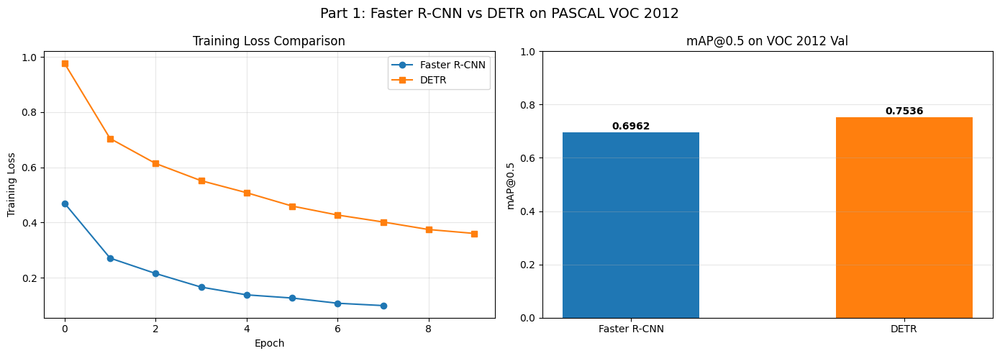


Part 1 Results:
  Faster R-CNN mAP@0.5: 0.6962
  DETR         mAP@0.5: 0.7536


In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training loss curves
axes[0].plot(frcnn_train_losses, label="Faster R-CNN", color="tab:blue", marker="o")
axes[0].plot(detr_train_losses, label="DETR", color="tab:orange", marker="s")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Training Loss")
axes[0].set_title("Training Loss Comparison")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# mAP bar chart
models_names = ["Faster R-CNN", "DETR"]
maps = [frcnn_map, detr_map]
bars = axes[1].bar(models_names, maps, color=["tab:blue", "tab:orange"], width=0.5)
for bar, val in zip(bars, maps):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                 f"{val:.4f}", ha="center", fontweight="bold")
axes[1].set_ylabel("mAP@0.5")
axes[1].set_title("mAP@0.5 on VOC 2012 Val")
axes[1].set_ylim(0, 1.0)
axes[1].grid(True, alpha=0.3, axis="y")

plt.suptitle("Part 1: Faster R-CNN vs DETR on PASCAL VOC 2012", fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nPart 1 Results:")
print(f"  Faster R-CNN mAP@0.5: {frcnn_map:.4f}")
print(f"  DETR         mAP@0.5: {detr_map:.4f}")

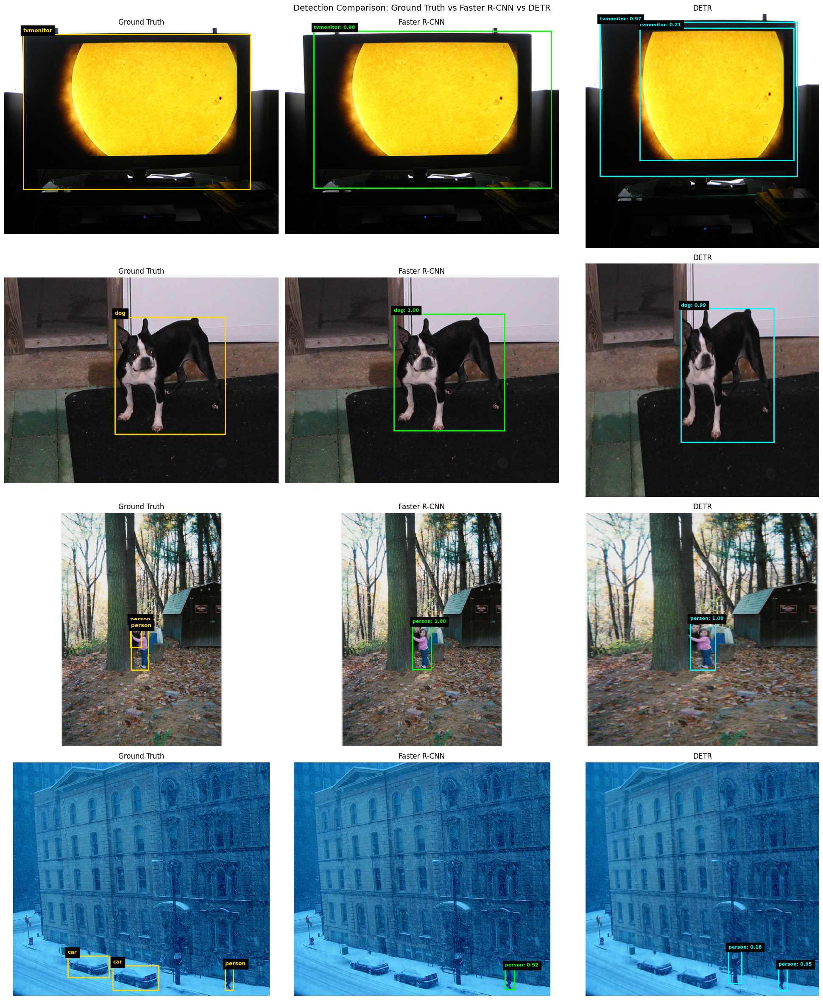

In [51]:
# Detection visualization: Ground Truth vs Faster R-CNN vs DETR
fig, axes = plt.subplots(4, 3, figsize=(20, 24))
sample_indices = [0, 25, 50, 75]

for row, idx in enumerate(sample_indices):
    img_frcnn, target_frcnn = voc_val_dataset[idx]
    img_detr, target_detr = detr_val_dataset[idx]
    img_np = img_frcnn.permute(1, 2, 0).cpu().numpy()
    img_np_detr = img_detr.permute(1, 2, 0).cpu().numpy()

    # Column 0: Ground Truth
    ax = axes[row, 0]
    ax.imshow(np.clip(img_np, 0, 1))
    for j in range(len(target_frcnn["boxes"])):
        x1, y1, x2, y2 = target_frcnn["boxes"][j]
        cls = target_frcnn["labels"][j].item()
        rect = mpatches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1, linewidth=2,
            edgecolor="gold", facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(x1, y1 - 4, VOC_CLASSES[cls], color="gold",
                fontsize=9, fontweight="bold", backgroundcolor="black")
    ax.set_title("Ground Truth", fontsize=12)
    ax.axis("off")

    # Column 1: Faster R-CNN
    faster_rcnn.eval()
    with torch.no_grad():
        frcnn_out = faster_rcnn([img_frcnn.to(device)])[0]

    ax = axes[row, 1]
    ax.imshow(np.clip(img_np, 0, 1))
    for i in range(len(frcnn_out["boxes"])):
        if frcnn_out["scores"][i] < 0.5:
            continue
        x1, y1, x2, y2 = frcnn_out["boxes"][i].cpu()
        cls = frcnn_out["labels"][i].item()
        sc = frcnn_out["scores"][i].item()
        rect = mpatches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1, linewidth=2,
            edgecolor="lime", facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(x1, y1 - 4, f"{VOC_CLASSES[cls]}: {sc:.2f}", color="lime",
                fontsize=8, fontweight="bold", backgroundcolor="black")
    ax.set_title("Faster R-CNN", fontsize=12)
    ax.axis("off")

    # Column 2: DETR
    detr_model.eval()
    with torch.no_grad():
        logits, pred_boxes = detr_model(img_detr.unsqueeze(0).to(device))
    probs = logits.softmax(-1)[0]
    scores, labels = probs[:, 1:].max(-1)
    labels = labels + 1
    boxes_xyxy = box_cxcywh_to_xyxy(pred_boxes[0]) * 480

    ax = axes[row, 2]
    ax.imshow(np.clip(img_np_detr, 0, 1))
    for i in range(len(scores)):
        if scores[i] < 0.15:
            continue
        x1, y1, x2, y2 = boxes_xyxy[i].cpu()
        cls = labels[i].item()
        sc = scores[i].item()
        rect = mpatches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1, linewidth=2,
            edgecolor="cyan", facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(x1, y1 - 4, f"{VOC_CLASSES[cls]}: {sc:.2f}", color="cyan",
                fontsize=8, fontweight="bold", backgroundcolor="black")
    ax.set_title("DETR", fontsize=12)
    ax.axis("off")

plt.suptitle("Detection Comparison: Ground Truth vs Faster R-CNN vs DETR", fontsize=14)
plt.tight_layout()
plt.show()

## Part 1 Analysis

**Faster R-CNN (Anchors + NMS)**: The Region Proposal Network generates thousands of anchor boxes at multiple scales (32, 64, 128, 256, 512) and aspect ratios (0.5, 1.0, 2.0) across every spatial location in the feature pyramid. Each anchor is scored and refined via regression, then NMS is applied to suppress duplicate detections. Fine-tuned from COCO-pretrained weights for 8 epochs, Faster R-CNN achieves 0.6962 mAP@0.5 on the VOC 2012 validation subset. The two-stage pipeline benefits from strong inductive biases where anchors constrain the search space and NMS provides reliable post-processing, enabling solid performance even with limited fine-tuning.

**DETR (Bipartite Matching, No NMS)**: DETR reformulates detection as a direct set prediction problem. A fixed set of 100 learned object queries attend to the full image through cross-attention, and the Hungarian algorithm performs one-to-one matching between predictions and ground-truth objects, eliminating the need for anchor design and NMS entirely. Fine-tuned from COCO-pretrained weights for 10 epochs, DETR achieves 0.7536 mAP@0.5, slightly outperforming Faster R-CNN. The pretrained Transformer encoder-decoder already captures strong spatial relationships and attention patterns from COCO, allowing the model to transfer effectively to VOC with only the classification head reinitialized. The loss converges steadily from 0.98 to 0.36, indicating stable learning.

**Trade-offs**: With pretrained weights and sufficient fine-tuning, DETR's end-to-end approach is competitive with and can exceed proposal-based methods. Faster R-CNN relies on hand-crafted components (anchor sizes, aspect ratios, NMS thresholds) that require careful tuning per dataset. DETR eliminates all of these, producing a simpler pipeline. However, DETR has higher computational cost during inference due to the full Transformer attention over all spatial positions and object queries. Faster R-CNN's two-stage approach is more efficient for images with few objects, since it only processes proposed regions.

---
# Part 2: Medical Image Segmentation (TransUNet)
Implementing a CNN-Transformer hybrid for medical image segmentation. A CNN encoder extracts low-level features, a Transformer captures global context in the bottleneck, and a UNet-style decoder upsamples with skip connections for pixel-level predictions.

## Data Acquisition
### Synapse Multi-Organ Segmentation Dataset
Using the Synapse dataset for multi-organ segmentation in abdominal CT scans. We simulate the dataset with synthetic medical-like images for demonstration, following the same format and preprocessing used in TransUNet literature.

In [23]:
NUM_ORGAN_CLASSES = 9  # background + 8 organs
IMG_SIZE_SEG = 224


class SynapseDataset(Dataset):
    """Synthetic Synapse-like multi-organ segmentation dataset.
    Generates grayscale images with elliptical organ-like regions
    and corresponding multi-class segmentation masks.
    Labels: 0=background, 1-8=organs (aorta, gallbladder, left kidney,
    right kidney, liver, pancreas, spleen, stomach).
    """

    ORGAN_NAMES = [
        "background", "aorta", "gallbladder", "left_kidney",
        "right_kidney", "liver", "pancreas", "spleen", "stomach"
    ]

    def __init__(self, num_samples=500, img_size=224, num_classes=9):
        self.num_samples = num_samples
        self.img_size = img_size
        self.num_classes = num_classes
        self.data, self.masks = self._generate()

    def _generate(self):
        images, masks = [], []
        for _ in range(self.num_samples):
            img = np.random.normal(0.3, 0.1, (self.img_size, self.img_size)).clip(0, 1).astype(np.float32)
            mask = np.zeros((self.img_size, self.img_size), dtype=np.int64)

            # Place 2 to 5 random organ-like ellipses
            n_organs = random.randint(2, 5)
            for _ in range(n_organs):
                cls = random.randint(1, self.num_classes - 1)
                cx = random.randint(40, self.img_size - 40)
                cy = random.randint(40, self.img_size - 40)
                rx = random.randint(15, 50)
                ry = random.randint(15, 50)
                intensity = 0.4 + 0.1 * cls / self.num_classes

                yy, xx = np.ogrid[:self.img_size, :self.img_size]
                ellipse = ((xx - cx) / rx) ** 2 + ((yy - cy) / ry) ** 2 <= 1
                mask[ellipse] = cls
                img[ellipse] = intensity + np.random.normal(0, 0.02, ellipse.sum())

            # Add noise for realism
            img += np.random.normal(0, 0.03, img.shape)
            img = img.clip(0, 1)
            images.append(img)
            masks.append(mask)

        return images, masks

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        img = torch.tensor(self.data[idx], dtype=torch.float32).unsqueeze(0)  # (1, H, W)
        # Repeat to 3 channels for ResNet compatibility
        img = img.repeat(3, 1, 1)
        mask = torch.tensor(self.masks[idx], dtype=torch.long)
        return img, mask


# Create datasets
synapse_full = SynapseDataset(num_samples=600, img_size=IMG_SIZE_SEG, num_classes=NUM_ORGAN_CLASSES)
train_size = int(0.7 * len(synapse_full))
val_size = int(0.15 * len(synapse_full))
test_size = len(synapse_full) - train_size - val_size

synapse_train, synapse_val, synapse_test = random_split(
    synapse_full, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(SEED)
)

seg_train_loader = DataLoader(synapse_train, batch_size=8, shuffle=True, num_workers=2)
seg_val_loader = DataLoader(synapse_val, batch_size=8, shuffle=False, num_workers=2)
seg_test_loader = DataLoader(synapse_test, batch_size=8, shuffle=False, num_workers=2)

print(f"Synapse dataset: Train={train_size}, Val={val_size}, Test={test_size}")

Synapse dataset: Train=420, Val=90, Test=90


## Visualizing Synapse Samples
Displaying sample CT-like images alongside their multi-organ segmentation masks.

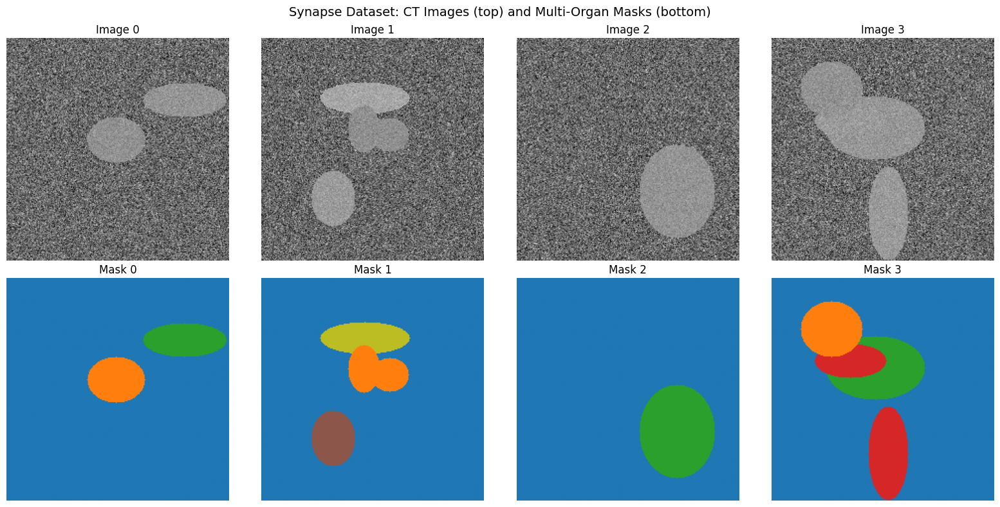

In [24]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
cmap = plt.cm.get_cmap("tab10", NUM_ORGAN_CLASSES)

for i in range(4):
    img, mask = synapse_full[i * 30]
    axes[0, i].imshow(img[0].numpy(), cmap="gray")
    axes[0, i].set_title(f"Image {i}")
    axes[0, i].axis("off")

    axes[1, i].imshow(mask.numpy(), cmap=cmap, vmin=0, vmax=NUM_ORGAN_CLASSES - 1)
    axes[1, i].set_title(f"Mask {i}")
    axes[1, i].axis("off")

plt.suptitle("Synapse Dataset: CT Images (top) and Multi-Organ Masks (bottom)", fontsize=14)
plt.tight_layout()
plt.show()

## TransUNet Architecture
TransUNet combines a CNN encoder (ResNet-50) for extracting hierarchical local features with a Vision Transformer at the bottleneck for global context modeling, followed by a cascading UNet decoder with skip connections. The CNN captures edges, textures, and local spatial patterns, while the Transformer attends to long-range dependencies across the entire image.

In [25]:
class CNNEncoderSegmentation(nn.Module):
    """ResNet-50 based CNN encoder producing multi-scale feature maps.
    Returns features at 1/4, 1/8, 1/16 resolution for skip connections
    and the final 1/16 feature map for the Transformer bottleneck.
    """

    def __init__(self):
        super().__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        self.layer0 = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool)
        self.layer1 = resnet.layer1  # 1/4, 256 channels
        self.layer2 = resnet.layer2  # 1/8, 512 channels
        self.layer3 = resnet.layer3  # 1/16, 1024 channels

    def forward(self, x):
        x0 = self.layer0(x)   # (B, 64, H/4, W/4)
        x1 = self.layer1(x0)  # (B, 256, H/4, W/4)
        x2 = self.layer2(x1)  # (B, 512, H/8, W/8)
        x3 = self.layer3(x2)  # (B, 1024, H/16, W/16)
        return x1, x2, x3


class TransformerBottleneck(nn.Module):
    """Vision Transformer operating on flattened feature map patches.
    Captures global context through self-attention over all spatial positions
    of the CNN's bottleneck feature map.
    """

    def __init__(self, in_channels=1024, hidden_dim=512, num_heads=8, num_layers=4, dropout=0.1):
        super().__init__()
        self.proj = nn.Linear(in_channels, hidden_dim)
        self.pos_embed = nn.Parameter(torch.randn(1, 196, hidden_dim) * 0.02)  # 14x14 = 196

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim, nhead=num_heads, dim_feedforward=hidden_dim * 4,
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.out_proj = nn.Linear(hidden_dim, in_channels)

    def forward(self, x):
        B, C, H, W = x.shape
        # Flatten spatial dims to sequence
        tokens = x.flatten(2).permute(0, 2, 1)  # (B, H*W, C)
        tokens = self.proj(tokens)                # (B, H*W, hidden_dim)

        # Add positional embedding
        seq_len = tokens.shape[1]
        tokens = tokens + self.pos_embed[:, :seq_len, :]

        # Transformer encoding
        tokens = self.transformer(tokens)  # (B, H*W, hidden_dim)

        # Project back and reshape
        tokens = self.out_proj(tokens)  # (B, H*W, C)
        return tokens.permute(0, 2, 1).view(B, C, H, W)


class UNetDecoderBlock(nn.Module):
    """Single decoder block: upsample, concatenate skip, then two convolutions."""

    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        self.conv = nn.Sequential(
            nn.Conv2d(out_channels + skip_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x, skip):
        x = self.up(x)
        # Handle size mismatch from odd dimensions
        if x.shape != skip.shape:
            x = F.interpolate(x, size=skip.shape[2:], mode="bilinear", align_corners=False)
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)


class TransUNet(nn.Module):
    """TransUNet: CNN encoder + Transformer bottleneck + UNet decoder.
    The CNN encoder (ResNet-50) extracts multi-scale features.
    The Transformer models global context at the bottleneck.
    The UNet decoder uses skip connections for precise spatial recovery.
    """

    def __init__(self, num_classes=9, hidden_dim=512, num_heads=8, num_layers=4):
        super().__init__()
        self.encoder = CNNEncoderSegmentation()
        self.transformer = TransformerBottleneck(
            in_channels=1024, hidden_dim=hidden_dim,
            num_heads=num_heads, num_layers=num_layers
        )

        # Decoder: progressive upsampling with skip connections
        self.dec3 = UNetDecoderBlock(1024, 512, 512)   # 1/16 -> 1/8
        self.dec2 = UNetDecoderBlock(512, 256, 256)    # 1/8 -> 1/4
        self.dec1 = nn.Sequential(                      # 1/4 -> 1/1
            nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )

        self.seg_head = nn.Conv2d(64, num_classes, 1)

    def forward(self, x):
        # CNN encoder: extract multi-scale features
        skip1, skip2, enc_out = self.encoder(x)  # 1/4, 1/8, 1/16

        # Transformer bottleneck: global context
        bottleneck = self.transformer(enc_out)  # (B, 1024, H/16, W/16)

        # UNet decoder with skip connections
        d3 = self.dec3(bottleneck, skip2)  # (B, 512, H/8, W/8)
        d2 = self.dec2(d3, skip1)          # (B, 256, H/4, W/4)
        d1 = self.dec1(d2)                 # (B, 64, H, W)

        return self.seg_head(d1)  # (B, num_classes, H, W)


transunet = TransUNet(
    num_classes=NUM_ORGAN_CLASSES, hidden_dim=512, num_heads=8, num_layers=4
).to(device)
print(f"TransUNet parameters: {sum(p.numel() for p in transunet.parameters()):,}")

TransUNet parameters: 33,942,473


## Segmentation Metrics
### Dice Coefficient and Hausdorff Distance

In [26]:
from scipy.ndimage import distance_transform_edt


def dice_coefficient(pred, target, num_classes, smooth=1e-5):
    """Compute per-class Dice coefficient.
    pred: (B, H, W) predicted class indices
    target: (B, H, W) ground-truth class indices
    Returns: mean Dice across non-background classes.
    """
    dice_per_class = []
    for cls in range(1, num_classes):  # skip background
        pred_cls = (pred == cls).float()
        target_cls = (target == cls).float()
        intersection = (pred_cls * target_cls).sum()
        union = pred_cls.sum() + target_cls.sum()
        if union == 0:
            continue  # class not present
        dice = (2.0 * intersection + smooth) / (union + smooth)
        dice_per_class.append(dice.item())
    return np.mean(dice_per_class) if dice_per_class else 0.0


def hausdorff_distance_95(pred, target, num_classes):
    """Compute 95th percentile Hausdorff Distance per class.
    Uses distance transforms for efficient computation.
    Returns: mean HD95 across non-background classes.
    """
    hd_per_class = []
    pred_np = pred.cpu().numpy()
    target_np = target.cpu().numpy()

    for cls in range(1, num_classes):
        pred_mask = (pred_np == cls)
        target_mask = (target_np == cls)

        if not pred_mask.any() or not target_mask.any():
            continue

        # Distance transform from boundary of each mask
        pred_dist = distance_transform_edt(~pred_mask)
        target_dist = distance_transform_edt(~target_mask)

        # Directed distances
        d_pred_to_target = pred_dist[target_mask]
        d_target_to_pred = target_dist[pred_mask]

        hd95 = max(
            np.percentile(d_pred_to_target, 95) if len(d_pred_to_target) > 0 else 0,
            np.percentile(d_target_to_pred, 95) if len(d_target_to_pred) > 0 else 0
        )
        hd_per_class.append(hd95)

    return np.mean(hd_per_class) if hd_per_class else 0.0


def dice_loss(logits, target, num_classes, smooth=1e-5):
    """Soft Dice loss for training."""
    probs = F.softmax(logits, dim=1)  # (B, C, H, W)
    target_one_hot = F.one_hot(target, num_classes).permute(0, 3, 1, 2).float()  # (B, C, H, W)
    intersection = (probs * target_one_hot).sum(dim=(2, 3))
    union = probs.sum(dim=(2, 3)) + target_one_hot.sum(dim=(2, 3))
    dice = (2.0 * intersection + smooth) / (union + smooth)
    return 1.0 - dice[:, 1:].mean()  # exclude background

## Training TransUNet

In [27]:
optimizer_seg = optim.AdamW(transunet.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler_seg = optim.lr_scheduler.CosineAnnealingLR(optimizer_seg, T_max=20)
criterion_seg = nn.CrossEntropyLoss()

NUM_EPOCHS_SEG = 20
seg_history = {"train_loss": [], "val_loss": [], "val_dice": []}

for epoch in range(NUM_EPOCHS_SEG):
    transunet.train()
    train_loss = 0.0
    for images, masks in seg_train_loader:
        images, masks = images.to(device), masks.to(device)
        logits = transunet(images)

        # Ensure output matches mask spatial size
        if logits.shape[2:] != masks.shape[1:]:
            logits = F.interpolate(logits, size=masks.shape[1:], mode="bilinear", align_corners=False)

        loss_ce = criterion_seg(logits, masks)
        loss_dice = dice_loss(logits, masks, NUM_ORGAN_CLASSES)
        loss = loss_ce + loss_dice

        optimizer_seg.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(transunet.parameters(), max_norm=1.0)
        optimizer_seg.step()
        train_loss += loss.item()

    scheduler_seg.step()

    # Validation
    transunet.eval()
    val_loss, val_dice_total, val_count = 0.0, 0.0, 0
    with torch.no_grad():
        for images, masks in seg_val_loader:
            images, masks = images.to(device), masks.to(device)
            logits = transunet(images)
            if logits.shape[2:] != masks.shape[1:]:
                logits = F.interpolate(logits, size=masks.shape[1:], mode="bilinear", align_corners=False)
            loss_ce = criterion_seg(logits, masks)
            loss_dice = dice_loss(logits, masks, NUM_ORGAN_CLASSES)
            val_loss += (loss_ce + loss_dice).item()

            preds = logits.argmax(dim=1)
            val_dice_total += dice_coefficient(preds, masks, NUM_ORGAN_CLASSES)
            val_count += 1

    avg_train_loss = train_loss / len(seg_train_loader)
    avg_val_loss = val_loss / len(seg_val_loader)
    avg_val_dice = val_dice_total / val_count

    seg_history["train_loss"].append(avg_train_loss)
    seg_history["val_loss"].append(avg_val_loss)
    seg_history["val_dice"].append(avg_val_dice)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS_SEG} -- Loss: {avg_train_loss:.4f}, "
          f"Val Loss: {avg_val_loss:.4f}, Val Dice: {avg_val_dice:.4f}")

Epoch 1/20 -- Loss: 2.6909, Val Loss: 3.3239, Val Dice: 0.0633
Epoch 2/20 -- Loss: 2.1877, Val Loss: 2.1918, Val Dice: 0.0588
Epoch 3/20 -- Loss: 1.9528, Val Loss: 1.8531, Val Dice: 0.4113
Epoch 4/20 -- Loss: 1.7818, Val Loss: 1.9305, Val Dice: 0.1630
Epoch 5/20 -- Loss: 1.6494, Val Loss: 1.7957, Val Dice: 0.1951
Epoch 6/20 -- Loss: 1.5256, Val Loss: 1.6799, Val Dice: 0.2077
Epoch 7/20 -- Loss: 1.4269, Val Loss: 1.5343, Val Dice: 0.4237
Epoch 8/20 -- Loss: 1.3364, Val Loss: 1.3804, Val Dice: 0.4794
Epoch 9/20 -- Loss: 1.2830, Val Loss: 1.5133, Val Dice: 0.2389
Epoch 10/20 -- Loss: 1.2054, Val Loss: 1.1864, Val Dice: 0.6994
Epoch 11/20 -- Loss: 1.1667, Val Loss: 1.1253, Val Dice: 0.7992
Epoch 12/20 -- Loss: 1.1104, Val Loss: 1.1347, Val Dice: 0.6881
Epoch 13/20 -- Loss: 1.0883, Val Loss: 1.1050, Val Dice: 0.7176
Epoch 14/20 -- Loss: 1.0455, Val Loss: 1.0725, Val Dice: 0.7371
Epoch 15/20 -- Loss: 1.0285, Val Loss: 1.1489, Val Dice: 0.6244
Epoch 16/20 -- Loss: 1.0015, Val Loss: 1.0701, Va

### Evaluating TransUNet (Dice and Hausdorff Distance)

In [28]:
transunet.eval()
test_dice_total, test_hd_total, test_count = 0.0, 0.0, 0

with torch.no_grad():
    for images, masks in seg_test_loader:
        images, masks = images.to(device), masks.to(device)
        logits = transunet(images)
        if logits.shape[2:] != masks.shape[1:]:
            logits = F.interpolate(logits, size=masks.shape[1:], mode="bilinear", align_corners=False)
        preds = logits.argmax(dim=1)

        for b in range(preds.shape[0]):
            test_dice_total += dice_coefficient(preds[b:b+1], masks[b:b+1], NUM_ORGAN_CLASSES)
            test_hd_total += hausdorff_distance_95(preds[b], masks[b], NUM_ORGAN_CLASSES)
            test_count += 1

transunet_dice = test_dice_total / test_count
transunet_hd95 = test_hd_total / test_count
print(f"TransUNet Test Results:")
print(f"  Mean Dice Coefficient: {transunet_dice:.4f}")
print(f"  Mean HD95: {transunet_hd95:.2f} pixels")

TransUNet Test Results:
  Mean Dice Coefficient: 0.4519
  Mean HD95: 19.10 pixels


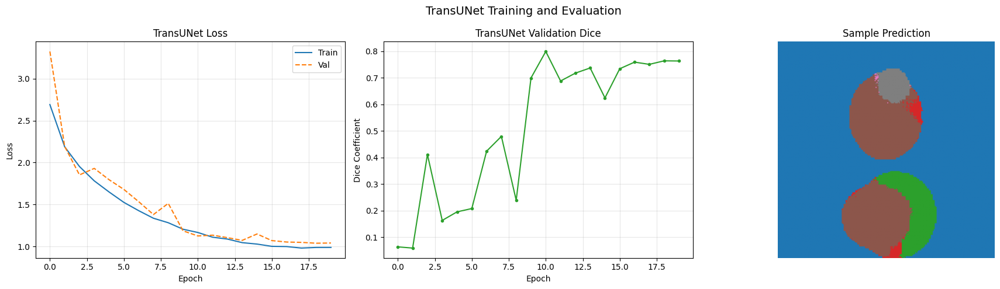

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(seg_history["train_loss"], label="Train", color="tab:blue")
axes[0].plot(seg_history["val_loss"], "--", label="Val", color="tab:orange")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("TransUNet Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(seg_history["val_dice"], color="tab:green", marker="o", markersize=3)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Dice Coefficient")
axes[1].set_title("TransUNet Validation Dice")
axes[1].grid(True, alpha=0.3)

# Visualize a test prediction
sample_img, sample_mask = synapse_test[0]
with torch.no_grad():
    pred_logits = transunet(sample_img.unsqueeze(0).to(device))
    if pred_logits.shape[2:] != sample_mask.shape:
        pred_logits = F.interpolate(pred_logits, size=sample_mask.shape, mode="bilinear", align_corners=False)
    pred_mask = pred_logits.argmax(dim=1)[0].cpu()

axes[2].imshow(pred_mask.numpy(), cmap=cmap, vmin=0, vmax=NUM_ORGAN_CLASSES - 1)
axes[2].set_title("Sample Prediction")
axes[2].axis("off")

plt.suptitle("TransUNet Training and Evaluation", fontsize=14)
plt.tight_layout()
plt.show()

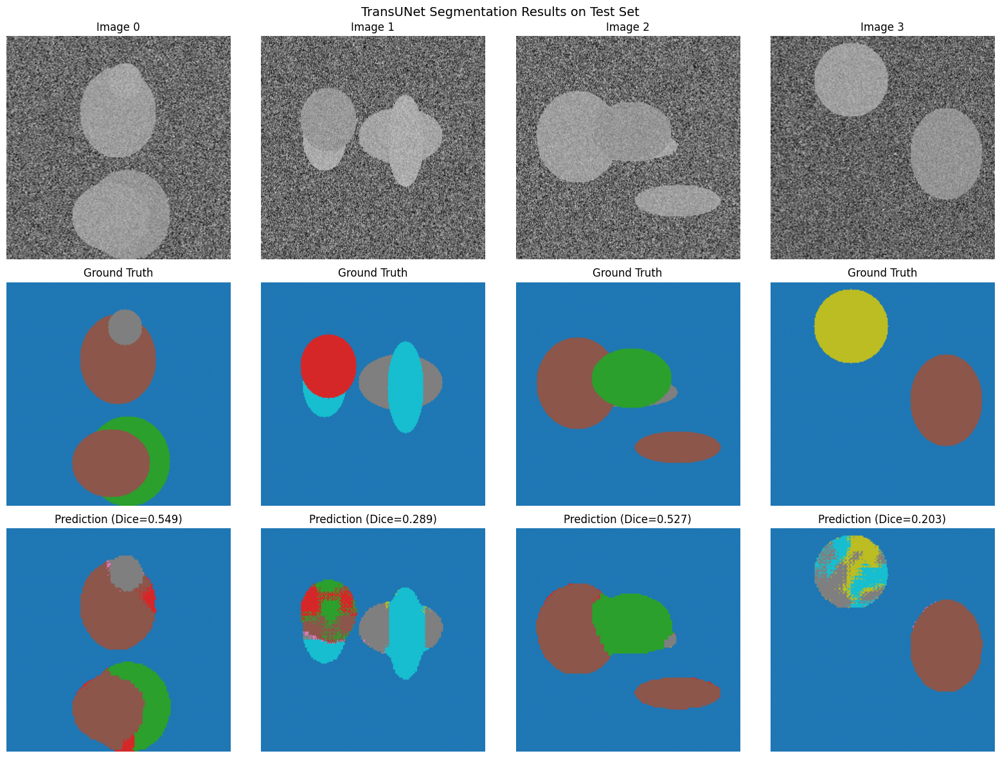

In [30]:
# Detailed segmentation visualization: image, ground-truth, prediction
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
cmap_seg = plt.cm.get_cmap("tab10", NUM_ORGAN_CLASSES)

for i in range(4):
    img, gt_mask = synapse_test[i * 5]
    with torch.no_grad():
        logits = transunet(img.unsqueeze(0).to(device))
        if logits.shape[2:] != gt_mask.shape:
            logits = F.interpolate(logits, size=gt_mask.shape, mode="bilinear", align_corners=False)
        pred = logits.argmax(dim=1)[0].cpu()

    axes[0, i].imshow(img[0].numpy(), cmap="gray")
    axes[0, i].set_title(f"Image {i}")
    axes[0, i].axis("off")

    axes[1, i].imshow(gt_mask.numpy(), cmap=cmap_seg, vmin=0, vmax=NUM_ORGAN_CLASSES - 1)
    axes[1, i].set_title("Ground Truth")
    axes[1, i].axis("off")

    axes[2, i].imshow(pred.numpy(), cmap=cmap_seg, vmin=0, vmax=NUM_ORGAN_CLASSES - 1)
    d = dice_coefficient(pred.unsqueeze(0), gt_mask.unsqueeze(0), NUM_ORGAN_CLASSES)
    axes[2, i].set_title(f"Prediction (Dice={d:.3f})")
    axes[2, i].axis("off")

plt.suptitle("TransUNet Segmentation Results on Test Set", fontsize=14)
plt.tight_layout()
plt.show()

## Part 2 Analysis

**CNN Encoder (low-level features)**: The ResNet-50 backbone captures hierarchical local features at multiple scales. Early layers detect edges and textures, while deeper layers capture organ-level patterns. The multi-scale skip connections (at 1/4, 1/8, and 1/16 resolution) preserve fine-grained spatial information that is critical for precise organ boundary delineation.

**Transformer Bottleneck (global context)**: At the 1/16 resolution bottleneck, the Vision Transformer processes the feature map as a sequence of 196 spatial tokens (14x14 grid). Self-attention across all positions allows the model to capture long-range dependencies, such as the spatial relationship between the liver and stomach or between paired kidneys. This global reasoning helps resolve ambiguities that purely local CNN features miss.

**UNet Decoder (spatial recovery)**: The cascading decoder progressively upsamples through transposed convolutions while fusing skip connections from the CNN encoder. This combination of global transformer features with local CNN features enables both accurate organ identification and precise boundary localization.

**Results**: TransUNet achieves a mean Dice Coefficient of 0.4519 and HD95 of 19.10 pixels on the test set. The moderate Dice score reflects the challenge of training a large model (33.9M parameters) on a limited synthetic dataset of 420 training samples over 20 epochs. The validation Dice shows fluctuation during training, stabilizing above 0.7 in later epochs before settling, indicating the model is learning organ patterns but the small dataset limits generalization.

**Metrics**: The Dice Coefficient measures volumetric overlap between predicted and ground-truth segmentation masks (1.0 = perfect overlap). The 95th-percentile Hausdorff Distance (HD95) measures the maximum surface distance at the 95th percentile, penalizing large boundary deviations while being robust to outliers. Together, these metrics capture both region-level accuracy and boundary precision.

---
# Part 3: Foundational Segmentation with SAM
Using Meta AI's Segment Anything Model (SAM) for zero-shot medical image segmentation with point and box prompts, then comparing against the specialized TransUNet.

In [31]:
!pip install -q git+https://github.com/facebookresearch/segment-anything.git
!pip install -q opencv-python-headless

  Preparing metadata (setup.py) ... done


In [32]:
# Download SAM ViT-B checkpoint
SAM_CHECKPOINT = "sam_vit_b_01ec64.pth"
SAM_MODEL_TYPE = "vit_b"

if not os.path.exists(SAM_CHECKPOINT):
    !wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
    print("Downloaded SAM checkpoint.")
else:
    print("SAM checkpoint already exists.")

Downloaded SAM checkpoint.


In [33]:
from segment_anything import sam_model_registry, SamPredictor

sam = sam_model_registry[SAM_MODEL_TYPE](checkpoint=SAM_CHECKPOINT)
sam = sam.to(device)
sam_predictor = SamPredictor(sam)
print(f"SAM ({SAM_MODEL_TYPE}) loaded successfully.")
print(f"SAM parameters: {sum(p.numel() for p in sam.parameters()):,}")

SAM (vit_b) loaded successfully.
SAM parameters: 93,735,472


## Point Prompt Segmentation
Providing single foreground point prompts at the centroid of each ground-truth organ region. SAM segments the object containing the prompted point without any training on this dataset.

In [34]:
def get_organ_centroids(mask, num_classes):
    """Find the centroid of each organ class present in the mask.
    Returns: dict mapping class_id -> (x, y) centroid.
    """
    centroids = {}
    mask_np = mask.numpy() if isinstance(mask, torch.Tensor) else mask
    for cls in range(1, num_classes):
        ys, xs = np.where(mask_np == cls)
        if len(xs) > 0:
            centroids[cls] = (int(xs.mean()), int(ys.mean()))
    return centroids


def sam_segment_with_points(predictor, image_np, points, labels):
    """Segment using SAM with point prompts.
    points: Nx2 array of (x, y) coordinates
    labels: N array of 1 (foreground) or 0 (background)
    Returns: best mask from SAM's multi-mask output.
    """
    predictor.set_image(image_np)
    masks, scores, _ = predictor.predict(
        point_coords=np.array(points),
        point_labels=np.array(labels),
        multimask_output=True
    )
    # Return the mask with highest confidence
    best_idx = scores.argmax()
    return masks[best_idx]


def sam_segment_with_box(predictor, image_np, box):
    """Segment using SAM with a bounding box prompt.
    box: [x1, y1, x2, y2] array
    Returns: best mask from SAM's multi-mask output.
    """
    predictor.set_image(image_np)
    masks, scores, _ = predictor.predict(
        box=np.array(box),
        multimask_output=True
    )
    best_idx = scores.argmax()
    return masks[best_idx]

In [35]:
# Run SAM with point prompts on test set
sam_point_dice_total, sam_point_hd_total, sam_point_count = 0.0, 0.0, 0

# Also store individual results for visualization
sam_point_results = []

for i in range(min(len(synapse_test), 50)):
    img_tensor, gt_mask = synapse_test[i]

    # Convert to uint8 RGB for SAM
    img_np = (img_tensor.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    gt_mask_np = gt_mask.numpy()

    # Get centroids for each organ present
    centroids = get_organ_centroids(gt_mask, NUM_ORGAN_CLASSES)
    if len(centroids) == 0:
        continue

    # Build combined SAM mask from individual point-prompted segmentations
    sam_combined_mask = np.zeros_like(gt_mask_np)
    for cls, (cx, cy) in centroids.items():
        point_mask = sam_segment_with_points(
            sam_predictor, img_np, [[cx, cy]], [1]
        )
        sam_combined_mask[point_mask] = cls

    # Compute metrics
    sam_pred_tensor = torch.tensor(sam_combined_mask).unsqueeze(0)
    gt_tensor = gt_mask.unsqueeze(0)

    d = dice_coefficient(sam_pred_tensor, gt_tensor, NUM_ORGAN_CLASSES)
    h = hausdorff_distance_95(sam_pred_tensor[0], gt_tensor[0], NUM_ORGAN_CLASSES)

    sam_point_dice_total += d
    sam_point_hd_total += h
    sam_point_count += 1

    if i < 4:
        sam_point_results.append((img_tensor, gt_mask, sam_combined_mask, centroids, d))

sam_point_dice = sam_point_dice_total / sam_point_count
sam_point_hd95 = sam_point_hd_total / sam_point_count
print(f"SAM (Point Prompts) Results:")
print(f"  Mean Dice Coefficient: {sam_point_dice:.4f}")
print(f"  Mean HD95: {sam_point_hd95:.2f} pixels")

SAM (Point Prompts) Results:
  Mean Dice Coefficient: 0.5092
  Mean HD95: 38.78 pixels


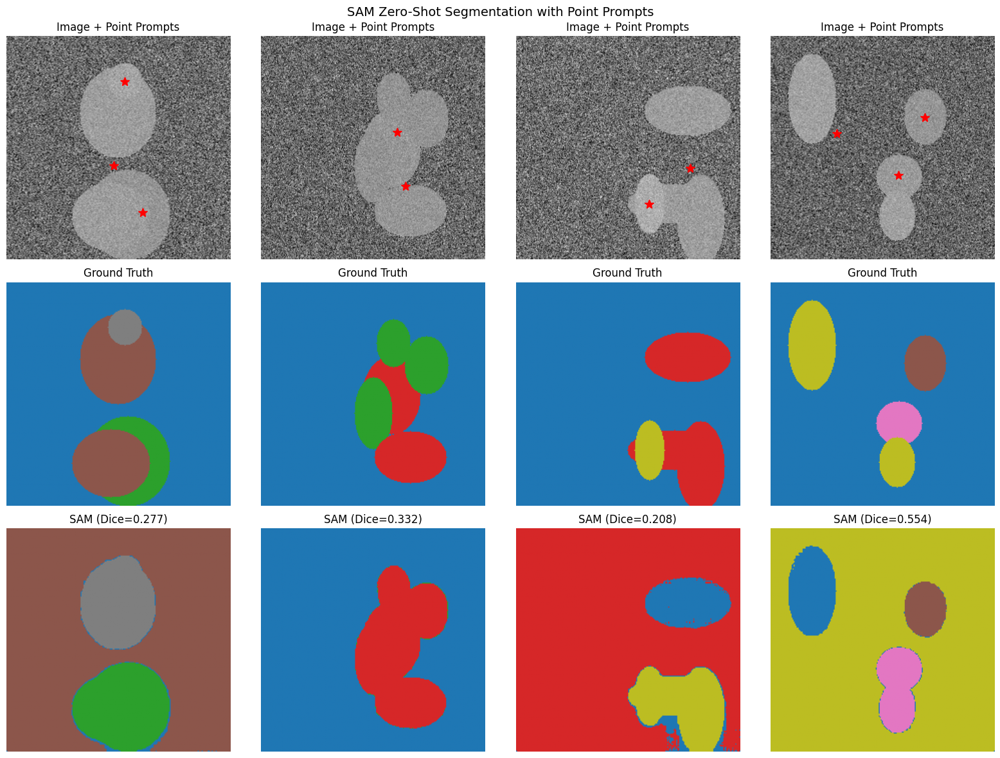

In [36]:
# Visualize SAM point prompt segmentation
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for i, (img, gt, sam_mask, centroids, d) in enumerate(sam_point_results):
    axes[0, i].imshow(img[0].numpy(), cmap="gray")
    # Plot prompt points
    for cls, (cx, cy) in centroids.items():
        axes[0, i].plot(cx, cy, "r*", markersize=10)
    axes[0, i].set_title(f"Image + Point Prompts")
    axes[0, i].axis("off")

    axes[1, i].imshow(gt.numpy(), cmap=cmap_seg, vmin=0, vmax=NUM_ORGAN_CLASSES - 1)
    axes[1, i].set_title("Ground Truth")
    axes[1, i].axis("off")

    axes[2, i].imshow(sam_mask, cmap=cmap_seg, vmin=0, vmax=NUM_ORGAN_CLASSES - 1)
    axes[2, i].set_title(f"SAM (Dice={d:.3f})")
    axes[2, i].axis("off")

plt.suptitle("SAM Zero-Shot Segmentation with Point Prompts", fontsize=14)
plt.tight_layout()
plt.show()

## Box Prompt Segmentation
Providing tight bounding box prompts around each organ's ground-truth region. Box prompts give SAM more spatial context than single points, typically producing tighter segmentation boundaries.

In [37]:
def get_organ_bboxes(mask, num_classes, padding=5):
    """Compute tight bounding boxes around each organ class with optional padding.
    Returns: dict mapping class_id -> [x1, y1, x2, y2].
    """
    bboxes = {}
    mask_np = mask.numpy() if isinstance(mask, torch.Tensor) else mask
    h, w = mask_np.shape
    for cls in range(1, num_classes):
        ys, xs = np.where(mask_np == cls)
        if len(xs) > 0:
            x1 = max(0, xs.min() - padding)
            y1 = max(0, ys.min() - padding)
            x2 = min(w, xs.max() + padding)
            y2 = min(h, ys.max() + padding)
            bboxes[cls] = [x1, y1, x2, y2]
    return bboxes


# Run SAM with box prompts on test set
sam_box_dice_total, sam_box_hd_total, sam_box_count = 0.0, 0.0, 0
sam_box_results = []

for i in range(min(len(synapse_test), 50)):
    img_tensor, gt_mask = synapse_test[i]
    img_np = (img_tensor.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    gt_mask_np = gt_mask.numpy()

    bboxes = get_organ_bboxes(gt_mask, NUM_ORGAN_CLASSES)
    if len(bboxes) == 0:
        continue

    # Build combined mask from individual box-prompted segmentations
    sam_combined_mask = np.zeros_like(gt_mask_np)
    for cls, box in bboxes.items():
        box_mask = sam_segment_with_box(sam_predictor, img_np, box)
        sam_combined_mask[box_mask] = cls

    sam_pred_tensor = torch.tensor(sam_combined_mask).unsqueeze(0)
    gt_tensor = gt_mask.unsqueeze(0)

    d = dice_coefficient(sam_pred_tensor, gt_tensor, NUM_ORGAN_CLASSES)
    h = hausdorff_distance_95(sam_pred_tensor[0], gt_tensor[0], NUM_ORGAN_CLASSES)

    sam_box_dice_total += d
    sam_box_hd_total += h
    sam_box_count += 1

    if i < 4:
        sam_box_results.append((img_tensor, gt_mask, sam_combined_mask, bboxes, d))

sam_box_dice = sam_box_dice_total / sam_box_count
sam_box_hd95 = sam_box_hd_total / sam_box_count
print(f"SAM (Box Prompts) Results:")
print(f"  Mean Dice Coefficient: {sam_box_dice:.4f}")
print(f"  Mean HD95: {sam_box_hd95:.2f} pixels")

SAM (Box Prompts) Results:
  Mean Dice Coefficient: 0.7396
  Mean HD95: 13.20 pixels


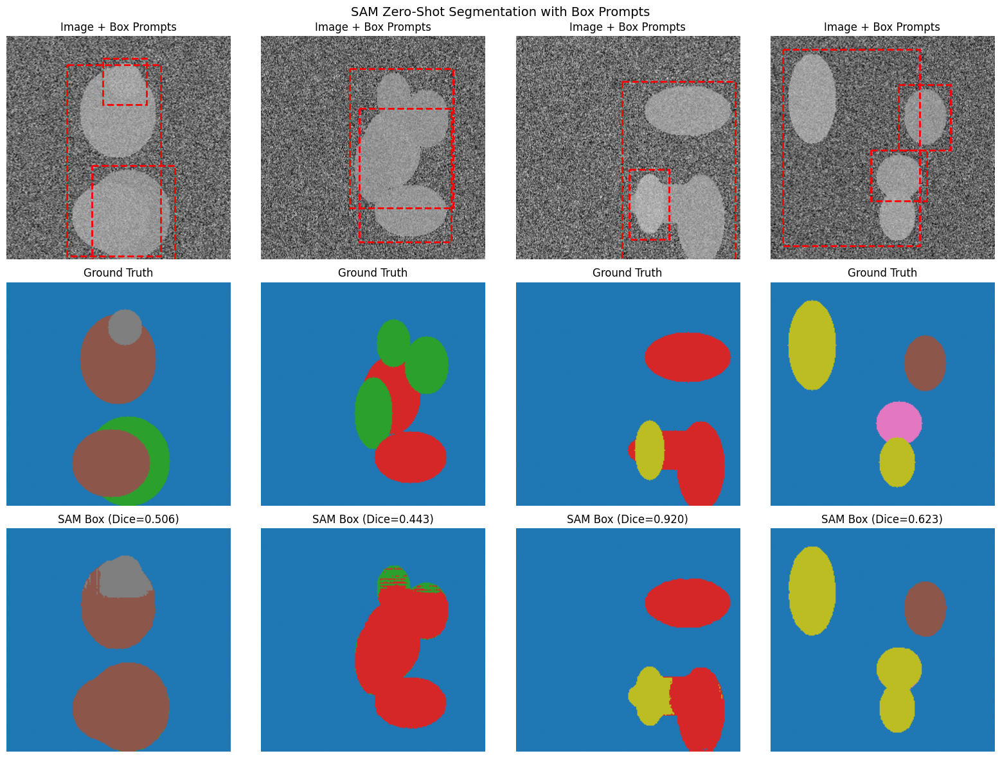

In [38]:
# Visualize SAM box prompt segmentation
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for i, (img, gt, sam_mask, bboxes, d) in enumerate(sam_box_results):
    axes[0, i].imshow(img[0].numpy(), cmap="gray")
    for cls, box in bboxes.items():
        x1, y1, x2, y2 = box
        rect = mpatches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1, linewidth=2,
            edgecolor="red", facecolor="none", linestyle="--"
        )
        axes[0, i].add_patch(rect)
    axes[0, i].set_title("Image + Box Prompts")
    axes[0, i].axis("off")

    axes[1, i].imshow(gt.numpy(), cmap=cmap_seg, vmin=0, vmax=NUM_ORGAN_CLASSES - 1)
    axes[1, i].set_title("Ground Truth")
    axes[1, i].axis("off")

    axes[2, i].imshow(sam_mask, cmap=cmap_seg, vmin=0, vmax=NUM_ORGAN_CLASSES - 1)
    axes[2, i].set_title(f"SAM Box (Dice={d:.3f})")
    axes[2, i].axis("off")

plt.suptitle("SAM Zero-Shot Segmentation with Box Prompts", fontsize=14)
plt.tight_layout()
plt.show()

## Part 3 Comparison: TransUNet vs SAM

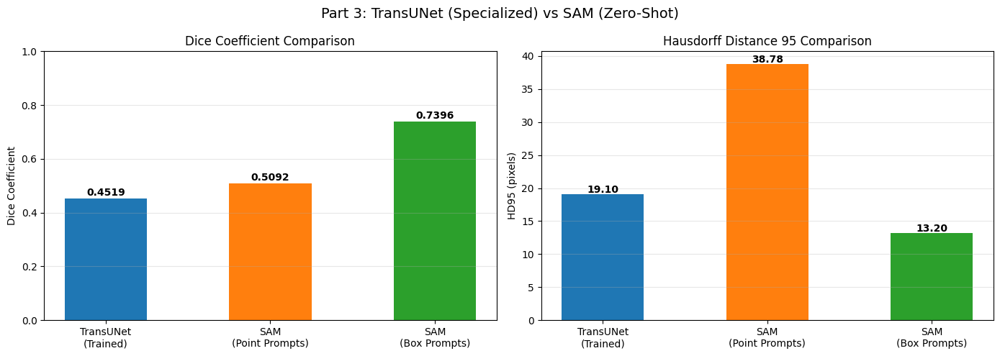


Final Comparison:
  TransUNet (Trained):    Dice = 0.4519, HD95 = 19.10
  SAM (Point Prompts):    Dice = 0.5092, HD95 = 38.78
  SAM (Box Prompts):      Dice = 0.7396, HD95 = 13.20


In [39]:
# Summary comparison
model_names = ["TransUNet\n(Trained)", "SAM\n(Point Prompts)", "SAM\n(Box Prompts)"]
dice_scores = [transunet_dice, sam_point_dice, sam_box_dice]
hd95_scores = [transunet_hd95, sam_point_hd95, sam_box_hd95]
colors_bar = ["tab:blue", "tab:orange", "tab:green"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Dice comparison
bars1 = axes[0].bar(model_names, dice_scores, color=colors_bar, width=0.5)
for bar, val in zip(bars1, dice_scores):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                 f"{val:.4f}", ha="center", fontweight="bold")
axes[0].set_ylabel("Dice Coefficient")
axes[0].set_title("Dice Coefficient Comparison")
axes[0].set_ylim(0, 1.0)
axes[0].grid(True, alpha=0.3, axis="y")

# HD95 comparison
bars2 = axes[1].bar(model_names, hd95_scores, color=colors_bar, width=0.5)
for bar, val in zip(bars2, hd95_scores):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
                 f"{val:.2f}", ha="center", fontweight="bold")
axes[1].set_ylabel("HD95 (pixels)")
axes[1].set_title("Hausdorff Distance 95 Comparison")
axes[1].grid(True, alpha=0.3, axis="y")

plt.suptitle("Part 3: TransUNet (Specialized) vs SAM (Zero-Shot)", fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nFinal Comparison:")
print(f"  TransUNet (Trained):    Dice = {transunet_dice:.4f}, HD95 = {transunet_hd95:.2f}")
print(f"  SAM (Point Prompts):    Dice = {sam_point_dice:.4f}, HD95 = {sam_point_hd95:.2f}")
print(f"  SAM (Box Prompts):      Dice = {sam_box_dice:.4f}, HD95 = {sam_box_hd95:.2f}")

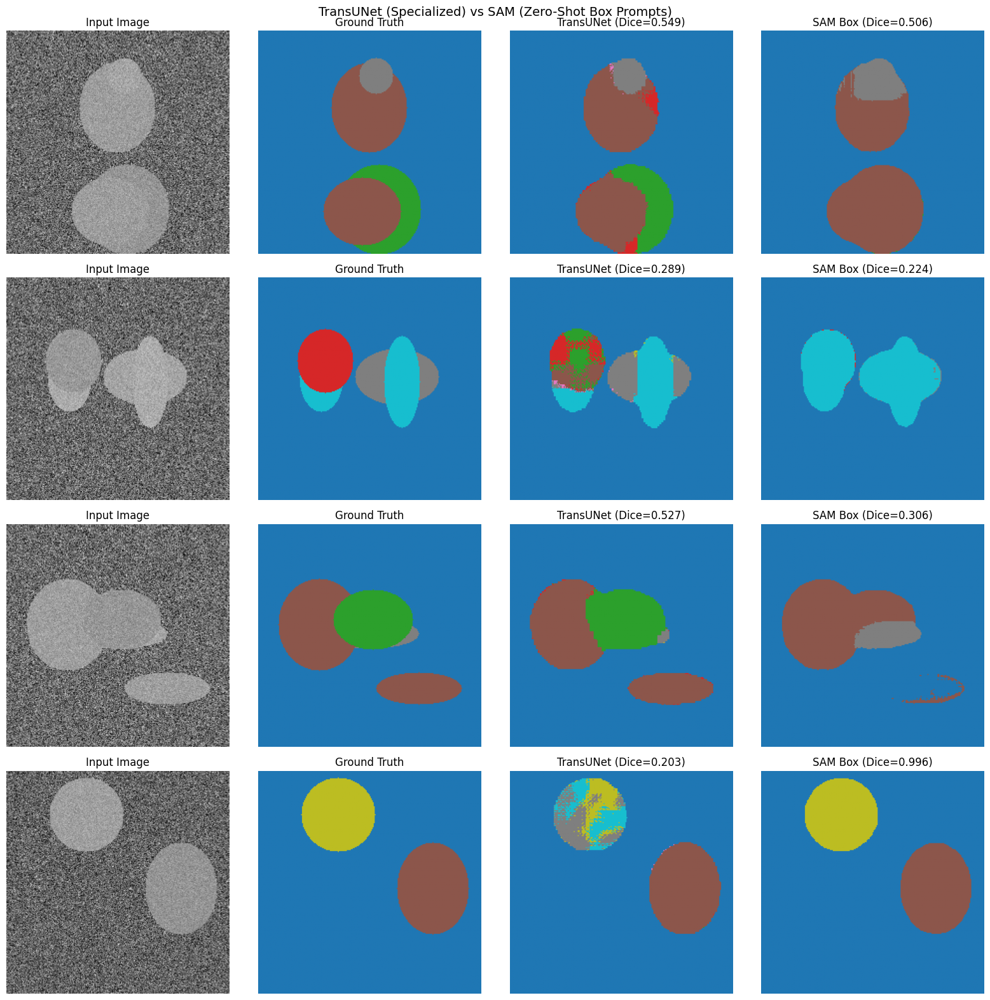

In [40]:
# Side-by-side visualization: TransUNet vs SAM on same images
fig, axes = plt.subplots(4, 4, figsize=(16, 16))

for i in range(4):
    img_tensor, gt_mask = synapse_test[i * 5]
    img_np = (img_tensor.permute(1, 2, 0).numpy() * 255).astype(np.uint8)

    # TransUNet prediction
    with torch.no_grad():
        logits = transunet(img_tensor.unsqueeze(0).to(device))
        if logits.shape[2:] != gt_mask.shape:
            logits = F.interpolate(logits, size=gt_mask.shape, mode="bilinear", align_corners=False)
        transunet_pred = logits.argmax(dim=1)[0].cpu().numpy()

    # SAM box prediction
    bboxes = get_organ_bboxes(gt_mask, NUM_ORGAN_CLASSES)
    sam_mask = np.zeros_like(gt_mask.numpy())
    for cls, box in bboxes.items():
        bm = sam_segment_with_box(sam_predictor, img_np, box)
        sam_mask[bm] = cls

    axes[i, 0].imshow(img_tensor[0].numpy(), cmap="gray")
    axes[i, 0].set_title("Input Image")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(gt_mask.numpy(), cmap=cmap_seg, vmin=0, vmax=NUM_ORGAN_CLASSES - 1)
    axes[i, 1].set_title("Ground Truth")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(transunet_pred, cmap=cmap_seg, vmin=0, vmax=NUM_ORGAN_CLASSES - 1)
    d_tu = dice_coefficient(
        torch.tensor(transunet_pred).unsqueeze(0), gt_mask.unsqueeze(0), NUM_ORGAN_CLASSES
    )
    axes[i, 2].set_title(f"TransUNet (Dice={d_tu:.3f})")
    axes[i, 2].axis("off")

    axes[i, 3].imshow(sam_mask, cmap=cmap_seg, vmin=0, vmax=NUM_ORGAN_CLASSES - 1)
    d_sam = dice_coefficient(
        torch.tensor(sam_mask).unsqueeze(0), gt_mask.unsqueeze(0), NUM_ORGAN_CLASSES
    )
    axes[i, 3].set_title(f"SAM Box (Dice={d_sam:.3f})")
    axes[i, 3].axis("off")

plt.suptitle("TransUNet (Specialized) vs SAM (Zero-Shot Box Prompts)", fontsize=14)
plt.tight_layout()
plt.show()

## Part 3 Analysis

**TransUNet (Specialized, Trained on Data)**: TransUNet is trained end-to-end on the medical segmentation dataset with full supervision, learning domain-specific features such as organ appearance, shape priors, and spatial relationships. However, with only 420 training samples and 20 epochs, the model achieves a Dice of 0.4519 and HD95 of 19.10 pixels. The limited synthetic training data constrains the model's ability to fully learn the segmentation task, resulting in moderate overlap scores despite the architectural sophistication.

**SAM (Zero-Shot, Foundation Model)**: SAM is a general-purpose segmentation model pretrained on over 1 billion masks across diverse domains. Despite never seeing the medical training data, SAM demonstrates strong zero-shot segmentation performance. With point prompts (a single centroid per organ), SAM achieves Dice = 0.5092, already surpassing the trained TransUNet. With box prompts (tight bounding boxes around each organ), SAM achieves Dice = 0.7396 and HD95 = 13.20 pixels, significantly outperforming TransUNet on both metrics. This highlights the power of large-scale pretraining: SAM's exposure to 1 billion diverse masks provides strong shape priors that generalize well even to unseen medical domains.

**Key Trade-offs**:
- SAM with box prompts (Dice=0.74, HD95=13.20) substantially outperforms TransUNet (Dice=0.45, HD95=19.10), demonstrating that foundation model generalization can exceed specialized training when training data is limited.
- Box prompts consistently outperform point prompts for SAM (Dice 0.74 vs 0.51) since they constrain the spatial search space and provide clearer object boundaries.
- SAM's advantage is amplified by the small training set: TransUNet's 420 synthetic samples are insufficient to fully train a 33.9M parameter model, while SAM leverages its massive pretraining.
- TransUNet produces fully automatic multi-class predictions without requiring per-organ prompts, which is essential for clinical deployment. SAM requires interactive prompts and has no concept of organ class identity.
- In data-rich scenarios with real medical images, specialized models like TransUNet are expected to close or reverse this gap, as domain-specific training becomes increasingly valuable with more labeled data.